In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
import os

load_dotenv()

if os.environ['GOOGLE_API_KEY']:
    print("Google API key is set")
else:
    raise ValueError("Google API key is not set")

Google API key is set


In [3]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=1.0,  # Gemini 3.0+ defaults to 1.0
    max_tokens=None,
    timeout=None,
    max_retries=2,
   # other params...
)

try :
  print("Dont waste Tokens")
 # print(model.invoke("I want to know about Langgraph ?"))
except:
  print("Something went wrong")

Dont waste Tokens


### LLM Pydantic Schema

In [8]:
from pydantic import BaseModel,Field
from typing import Literal

class llm_schema(BaseModel):
    category: Literal['insta','twitter','linkedin'] = Field(...,description="Category of the post to generate")
    topic: str = Field(...,description="Topic of the post to generate")

In [9]:
llm_with_schema=model.with_structured_output(llm_schema)

In [7]:
llm_with_schema.invoke("I want to generate a post for twitter about Rajamouli")

llm_schema(topic='twitter')

###  Schema

In [17]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    inputs : str
    topic : str
    post : str
    category : str


In [27]:
def decider_node(state: graph_schema)-> graph_schema:
    # Extract the input from state
    user_input=state['inputs']

    #Passing the user input to the LLM to decide the category of the post to generate
    llm_with_schema_output = llm_with_schema.invoke(user_input)
    category=llm_with_schema_output.category
    topic=llm_with_schema_output.topic

    #Update the state with the decided category

    state['category'] = category
    state['topic'] = topic
    return state

def create_post_insta(state: graph_schema)-> graph_schema:
#We generally refer a pydantic object using . operator like below
#    topic = state.topic

#Extract the topic from the state
    topic=state["topic"]

#Passing the topic to the LLM to generate a LinkedIn Post
    post=model.invoke(f"Write a Instagram post about {topic}. Keep the tone casual and engaging").content

#Update the state with the generated post
    state['post'] = post

    return {'post': post}

def create_post_twitter(state: graph_schema)-> graph_schema:
#We generally refer a pydantic object using . operator like below
#    topic = state.topic

#Extract the topic from the state
    topic=state["topic"]

#Passing the topic to the LLM to generate a LinkedIn Post
    post=model.invoke(f"Write a Twitter post about {topic}. Keep the tone quick").content

#Update the state with the generated post
    state['post'] = post

    return {'post': post}

def create_post_linkedin(state: graph_schema)-> graph_schema:
#We generally refer a pydantic object using . operator like below
#    topic = state.topic

#Extract the topic from the state
    topic=state["topic"]

#Passing the topic to the LLM to generate a LinkedIn Post
    post=model.invoke(f"Write a LinkedIn post about {topic}. Keep the tone professional and informative").content

#Update the state with the generated post
    state['post'] = post

    return {'post': post}

In [28]:
def condition(state: graph_schema) -> str:
    category=state['category']

    if category =='insta':
        return 'create_post_insta'
    elif category =='twitter':
        return 'create_post_twitter'
    elif category =='linkedin':
        return 'create_post_linkedin'
    else:
        return ValueError("Invalid Category")


In [29]:
from langgraph.graph import StateGraph, START, END 

graph = StateGraph(graph_schema)

graph.add_node("decider",decider_node)
graph.add_node("create_post_linkedin",create_post_linkedin)
graph.add_node("create_post_insta",create_post_insta)
graph.add_node("create_post_twitter",create_post_twitter)

graph.add_edge(START, "decider")
graph.add_conditional_edges("decider", condition,{"create_post_linkedin":"create_post_linkedin","create_post_insta":"create_post_insta","create_post_twitter":"create_post_twitter"})
#graph.add_edge("decider", "create_post_twitter") #Gives solid edges
#graph.add_edge("decider", "create_post_linkedin") #Gives solid edges
#graph.add_edge("decider", "create_post_insta") #Gives solid edges
graph.add_edge("create_post_insta", END)
graph.add_edge("create_post_linkedin", END)
graph.add_edge("create_post_twitter", END)


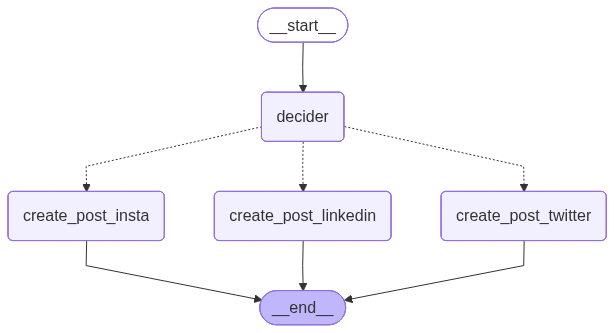

In [30]:
from IPython.display import Image, display

route_graph=graph.compile()

Image(route_graph.get_graph().draw_mermaid_png())

In [31]:
route_graph.invoke(
    {"inputs" : "I want to write a instagram post about SS Rajamouli",
    "topic" : "",
    "post" : "",
    "category" : ""
    }

)

{'inputs': 'I want to write a instagram post about SS Rajamouli',
 'topic': 'SS Rajamouli',
 'post': 'Here are a few options, pick the one that best fits your vibe!\n\n**Option 1 (Focus on vision/universes):**\n\nCan we just take a moment to appreciate the absolute genius that is SS Rajamouli? ✨ Seriously, the man doesn\'t just make movies, he *creates entire universes*. From the epic scale of Baahubali and the global phenomenon that is RRR, to even the utterly unique charm of Eega (Makkhi in Hindi!) – Jakkanna\'s imagination knows no bounds. Every single frame is a testament to his incredible vision. 🎬\n\nWhich of his films blew your mind the most? And what scene lives rent-free in your head? Drop your faves below! 👇\n\n#SSRajamouli #Jakkanna #IndianCinema #Baahubali #RRR #Eega #MasterStoryteller #Filmmaker #Visionary #MovieMagic\n\n---\n\n**Option 2 (More direct, "ride" theme):**\n\nWhen SS Rajamouli\'s name pops up, you just *know* you\'re in for a wild ride! 🤯 This man has redefine